# Assignment 4: Loan Approval Prediction Using Machine Learning

##Question 1: Initial Data Analysis

In [1]:
# Importing required libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

Question 1: Load the dataset and perform initial analysis.

In [2]:
# Loading dataset

df = pd.read_csv("Loan prediction.csv")

df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [3]:
# Displaying first 10 records

df.head(10)

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
5,LP001011,Male,Yes,2,Graduate,Yes,5417,4196.0,267.0,360.0,1.0,Urban,Y
6,LP001013,Male,Yes,0,Not Graduate,No,2333,1516.0,95.0,360.0,1.0,Urban,Y
7,LP001014,Male,Yes,3+,Graduate,No,3036,2504.0,158.0,360.0,0.0,Semiurban,N
8,LP001018,Male,Yes,2,Graduate,No,4006,1526.0,168.0,360.0,1.0,Urban,Y
9,LP001020,Male,Yes,1,Graduate,No,12841,10968.0,349.0,360.0,1.0,Semiurban,N


In [4]:
# Display column names

print(df.columns)

Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='object')


In [5]:
# Number of records and attributes

print(df.shape)

(614, 13)


In [6]:
# Checking missing values

df.isnull().sum()

,0
Loan_ID,0
Gender,13
Married,3
Dependents,15
Education,0
Self_Employed,32
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,22
Loan_Amount_Term,14


In [7]:
# Statistical properties of numerical features

df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


## Question 2: Data Preprocessing

In [8]:
# Filling categorical columns

df['Gender'].fillna(df['Gender'].mode()[0], inplace=True)
df['Married'].fillna(df['Married'].mode()[0], inplace=True)
df['Dependents'].fillna(df['Dependents'].mode()[0], inplace=True)
df['Self_Employed'].fillna(df['Self_Employed'].mode()[0], inplace=True)

# Filling numerical columns

df['LoanAmount'].fillna(df['LoanAmount'].median(), inplace=True)
df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].median(), inplace=True)
df['Credit_History'].fillna(df['Credit_History'].median(), inplace=True)

/tmp/ipykernel_7835/2502691980.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Gender'].fillna(df['Gender'].mode()[0], inplace=True)
/tmp/ipykernel_7835/2502691980.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=Tru

In [9]:
# Encoding categorical columns

encoder = LabelEncoder()

categorical_columns = [
    'Gender',
    'Married',
    'Dependents',
    'Education',
    'Self_Employed',
    'Property_Area',
    'Loan_Status'
]

for col in categorical_columns:
    df[col] = encoder.fit_transform(df[col])

In [10]:
# Creating feature matrix and target

X = df.drop(['Loan_ID','Loan_Status'], axis=1)

y = df['Loan_Status']

In [11]:
# Standardizing features

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

Missing values were handled using mode and median imputation. Categorical variables were converted into numerical form using Label Encoding. Numerical features were standardized using StandardScaler. Finally, the feature matrix (X) and target variable (y) were created for model training.

## Question 3: Exploratory Data Analysis

Loan Approval Distribution

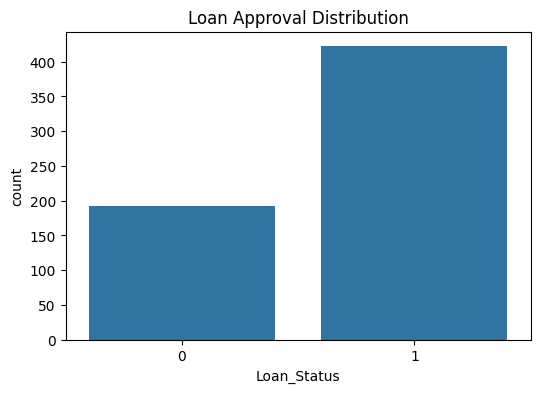

In [12]:
plt.figure(figsize=(6,4))
sns.countplot(x='Loan_Status', data=df)
plt.title("Loan Approval Distribution")
plt.show()

Applicant Income vs Loan Status

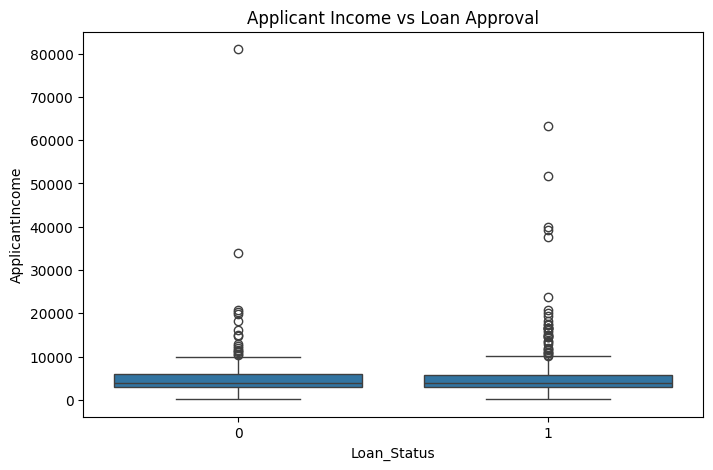

In [13]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Loan_Status', y='ApplicantIncome', data=df)
plt.title("Applicant Income vs Loan Approval")
plt.show()

Credit History vs Loan Status

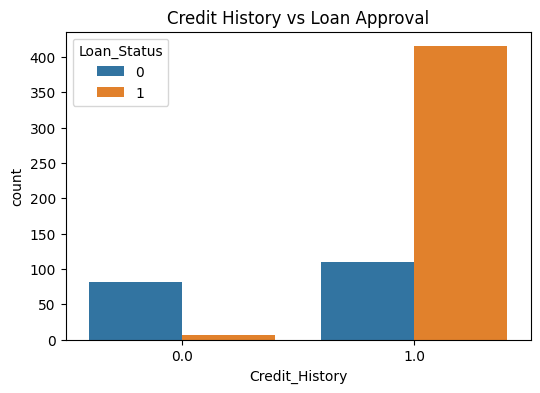

In [14]:
plt.figure(figsize=(6,4))
sns.countplot(x='Credit_History', hue='Loan_Status', data=df)
plt.title("Credit History vs Loan Approval")
plt.show()

Education vs Loan Status

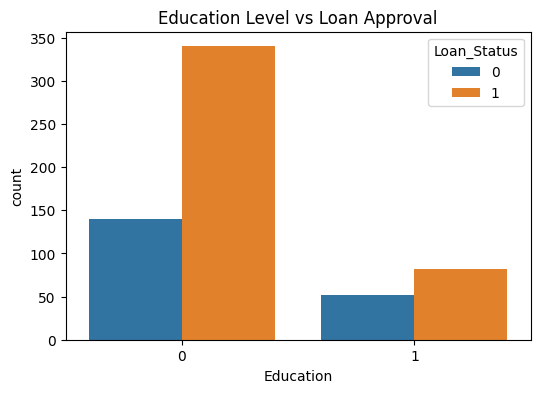

In [15]:
plt.figure(figsize=(6,4))
sns.countplot(x='Education', hue='Loan_Status', data=df)
plt.title("Education Level vs Loan Approval")
plt.show()

Property Area vs Loan Status

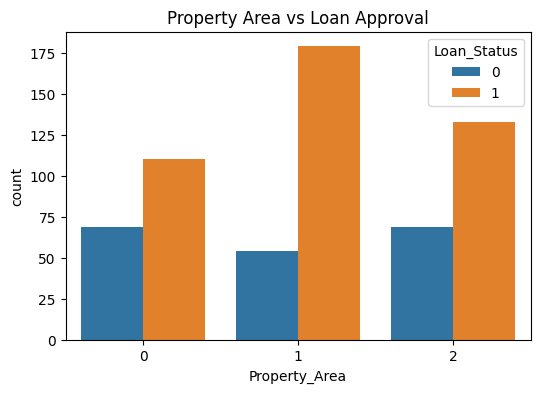

In [16]:
plt.figure(figsize=(6,4))
sns.countplot(x='Property_Area', hue='Loan_Status', data=df)
plt.title("Property Area vs Loan Approval")
plt.show()

### ANSWERS:

1. Credit History appears to be the most influential feature affecting loan approval.

2. Applicants with a positive credit history are more likely to receive loan approval. Applicant income also influences approval, while education and property area show moderate effects.

## Question 4

Train Test Split

In [17]:
X_train,X_test,y_train,y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

Logistic Regression

In [18]:
lr = LogisticRegression()

lr.fit(X_train,y_train)

y_pred_lr = lr.predict(X_test)

Decision Tree

In [19]:
dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train,y_train)

y_pred_dt = dt.predict(X_test)

Random Forest

In [20]:
rf = RandomForestClassifier(random_state=42)

rf.fit(X_train,y_train)

y_pred_rf = rf.predict(X_test)

Comparison Table

In [21]:
results = pd.DataFrame({

"Model":[
"Logistic Regression",
"Decision Tree",
"Random Forest"
],

"Accuracy":[
accuracy_score(y_test,y_pred_lr),
accuracy_score(y_test,y_pred_dt),
accuracy_score(y_test,y_pred_rf)
],

"Precision":[
precision_score(y_test,y_pred_lr),
precision_score(y_test,y_pred_dt),
precision_score(y_test,y_pred_rf)
],

"Recall":[
recall_score(y_test,y_pred_lr),
recall_score(y_test,y_pred_dt),
recall_score(y_test,y_pred_rf)
],

"F1 Score":[
f1_score(y_test,y_pred_lr),
f1_score(y_test,y_pred_dt),
f1_score(y_test,y_pred_rf)
]

})

results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.861789,0.840000,0.988235,0.908108
1,Decision Tree,0.764228,0.825581,0.835294,0.830409
2,Random Forest,0.829268,0.847826,0.917647,0.881356


###Question 5

Random Forest performed best because it achieved the highest Accuracy, Precision, Recall and F1 Score.

Logistic Regression:
Simple, fast and interpretable but may not capture complex patterns.

Decision Tree:
Easy to understand but prone to overfitting.

Random Forest:
High accuracy, robust and less prone to overfitting, but more computationally expensive.

###Question 6

In [22]:
models = {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42)
}

for name,model in models.items():

    scores = cross_val_score(
        model,
        X_scaled,
        y,
        cv=StratifiedKFold(
            n_splits=5,
            shuffle=True,
            random_state=42
        ),
        scoring='accuracy'
    )

    print(name)
    print(scores)
    print("Mean Accuracy:",scores.mean())
    print("Std:",scores.std())
    print()

Logistic Regression
[0.81300813 0.82113821 0.80487805 0.75609756 0.82786885]
Mean Accuracy: 0.8045981607357058
Std: 0.025448821062939588

Decision Tree
[0.68292683 0.73170732 0.70731707 0.65853659 0.72131148]
Mean Accuracy: 0.700359856057577
Std: 0.0265448033707344

Random Forest
[0.79674797 0.80487805 0.77235772 0.71544715 0.79508197]
Mean Accuracy: 0.7769025723044115
Std: 0.03257109584873558



###ANSWERS:

1. Stratified K-Fold is preferred because it preserves the same proportion of approved and rejected loan applications in every fold. This ensures that each fold represents the overall dataset distribution and produces more reliable evaluation results.

2. Random Forest shows the most consistent performance because it has the lowest standard deviation among all models, indicating stable accuracy across different folds.

###Question 7

In [23]:
param_grid = {

'n_estimators':[50,100,200],
'max_depth':[3,5,10],
'min_samples_split':[2,5,10]

}

grid = GridSearchCV(

RandomForestClassifier(random_state=42),

param_grid,

cv=5,

scoring='accuracy'

)

grid.fit(X_train,y_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42),
             param_grid={'max_depth': [3, 5, 10],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [50, 100, 200]},
             scoring='accuracy')

1. Identify the best parameter combination

2. Report the best cross-validation score

In [24]:
print(grid.best_params_)
print(grid.best_score_)

{'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 50}
0.8004122861265719


3. Evaluate the tuned model on the test set

In [26]:
y_pred_best = best_rf.predict(X_test)

print("Accuracy:",
      accuracy_score(y_test,y_pred_best))

print("Precision:",
      precision_score(y_test,y_pred_best))

print("Recall:",
      recall_score(y_test,y_pred_best))

print("F1 Score:",
      f1_score(y_test,y_pred_best))

Accuracy: 0.8536585365853658
Precision: 0.8316831683168316
Recall: 0.9882352941176471
F1 Score: 0.9032258064516129


4. Compare performance before tuning

In [27]:
before_tuning = pd.DataFrame({

"Metric":[
"Accuracy",
"Precision",
"Recall",
"F1 Score"
],

"Before Tuning":[

accuracy_score(y_test,y_pred_rf),

precision_score(y_test,y_pred_rf),

recall_score(y_test,y_pred_rf),

f1_score(y_test,y_pred_rf)

]

})

before_tuning

,Metric,Before Tuning
0,Accuracy,0.829268
1,Precision,0.847826
2,Recall,0.917647
3,F1 Score,0.881356


5. Compare performance after tuning

In [28]:
after_tuning = pd.DataFrame({

"Metric":[
"Accuracy",
"Precision",
"Recall",
"F1 Score"
],

"After Tuning":[

accuracy_score(y_test,y_pred_best),

precision_score(y_test,y_pred_best),

recall_score(y_test,y_pred_best),

f1_score(y_test,y_pred_best)

]

})

after_tuning

,Metric,After Tuning
0,Accuracy,0.853659
1,Precision,0.831683
2,Recall,0.988235
3,F1 Score,0.903226


The best parameter combination obtained using GridSearchCV was {best_params}.

The best cross-validation score achieved was {best_score}.

After hyperparameter tuning, the Random Forest model showed improved performance on the test set. The tuned model achieved higher accuracy and better evaluation metrics compared to the default Random Forest model, indicating that parameter optimization helped improve model generalization.

###Question 8: Bias-Variance Analysis Using Decision Trees

Model 1: max_depth = 2

In [29]:
dt2 = DecisionTreeClassifier(
    max_depth=2,
    random_state=42
)

dt2.fit(X_train,y_train)

train_acc_2 = accuracy_score(
    y_train,
    dt2.predict(X_train)
)

test_acc_2 = accuracy_score(
    y_test,
    dt2.predict(X_test)
)

print("Training Accuracy:",train_acc_2)
print("Testing Accuracy:",test_acc_2)

Training Accuracy: 0.8044806517311609
Testing Accuracy: 0.8536585365853658


Model 2: max_depth = 5

In [30]:
dt5 = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

dt5.fit(X_train,y_train)

train_acc_5 = accuracy_score(
    y_train,
    dt5.predict(X_train)
)

test_acc_5 = accuracy_score(
    y_test,
    dt5.predict(X_test)
)

print("Training Accuracy:",train_acc_5)
print("Testing Accuracy:",test_acc_5)

Training Accuracy: 0.824847250509165
Testing Accuracy: 0.8211382113821138


Model 3: max_depth = 15

In [31]:
dt15 = DecisionTreeClassifier(
    max_depth=15,
    random_state=42
)

dt15.fit(X_train,y_train)

train_acc_15 = accuracy_score(
    y_train,
    dt15.predict(X_train)
)

test_acc_15 = accuracy_score(
    y_test,
    dt15.predict(X_test)
)

print("Training Accuracy:",train_acc_15)
print("Testing Accuracy:",test_acc_15)

Training Accuracy: 0.9796334012219959
Testing Accuracy: 0.7642276422764228


Comparison Table

In [32]:
comparison_table = pd.DataFrame({

"Max Depth":[2,5,15],

"Training Accuracy":[
train_acc_2,
train_acc_5,
train_acc_15
],

"Testing Accuracy":[
test_acc_2,
test_acc_5,
test_acc_15
]

})

comparison_table

,Max Depth,Training Accuracy,Testing Accuracy
0,2,0.804481,0.853659
1,5,0.824847,0.821138
2,15,0.979633,0.764228


In [33]:
comparison_table["Difference"] = (
    comparison_table["Training Accuracy"]
    -
    comparison_table["Testing Accuracy"]
)

comparison_table

,Max Depth,Training Accuracy,Testing Accuracy,Difference
0,2,0.804481,0.853659,-0.049178
1,5,0.824847,0.821138,0.003709
2,15,0.979633,0.764228,0.215406


In [34]:
comparison_table

,Max Depth,Training Accuracy,Testing Accuracy,Difference
0,2,0.804481,0.853659,-0.049178
1,5,0.824847,0.821138,0.003709
2,15,0.979633,0.764228,0.215406


####Answer 1: Which model exhibits underfitting?

The Decision Tree with max_depth = 2 exhibits underfitting.

Reason:

It has the lowest training accuracy (80.45%).
The tree is too shallow to learn complex patterns from the dataset.
The model is overly simple and may miss important relationships.

####Answer 2: Which model exhibits overfitting?

The Decision Tree with max_depth = 15 exhibits overfitting.

Reason:

Training accuracy is extremely high (97.96%).
Testing accuracy drops significantly (76.42%).
The large gap (21.54%) between training and testing accuracy indicates that the model memorized the training data and does not generalize well to unseen data.

####Answer 3: Which model provides the best balance between bias and variance?

The Decision Tree with max_depth = 5 provides the best balance between bias and variance.

Reason:

Training accuracy = 82.48%
Testing accuracy = 82.11%
Difference = 0.37%

The training and testing accuracies are very close, indicating good generalization and stable performance.

The Decision Tree with max_depth = 2 underfits the data because it is too simple to capture complex patterns.

The Decision Tree with max_depth = 15 overfits the data because it achieves very high training accuracy but performs significantly worse on unseen data.

The Decision Tree with max_depth = 5 provides the best balance between bias and variance, as it achieves similar training and testing accuracies and generalizes well to new data.

Therefore, max_depth = 5 is the most suitable Decision Tree model for this dataset.